In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.stats import spearmanr


In [13]:
df = pd.read_parquet('../data/vrpp_df.parquet')
df.head()

,Berth ID,Vessel ID,Local Port,Remote Port,Trade,Container Type,ETA,ETD,Has Dangerous Cargo,Dry/Reefer,Container Size,Weight KGS,Arrival Date,Sailing Date,Containers,Delay Duration,TEU,Delay_Status,Sailing Season,Delay_Hours
0,1,Vessel_001,BREMERHAVEN,NANSHA,SOUTH CHINA + HONG KONG,40HC,2025-01-03,2025-01-05,False,Dry,40,7640.00,2024-12-31,2025-01-01,1,4.00:00:00,2,Major Delay,Winter,96.0
1,2,Vessel_001,FELIXSTOWE,NANSHA,SOUTH CHINA + HONG KONG,40HC,2025-01-03,2025-01-05,False,Dry,40,15040.00,2024-12-31,2025-01-01,1,4.00:00:00,2,Major Delay,Winter,96.0
2,3,Vessel_001,HAMBURG,NANSHA,SOUTH CHINA + HONG KONG,45HC,2025-01-06,2025-01-09,False,Dry,45,18310.00,2025-01-02,2025-01-05,1,4.00:00:00,1,Major Delay,Winter,96.0
3,4,Vessel_001,HAMBURG,NANSHA,SOUTH CHINA + HONG KONG,20DV,2025-01-06,2025-01-09,False,Dry,20,17290.00,2025-01-02,2025-01-05,1,4.00:00:00,1,Major Delay,Winter,96.0
4,4,Vessel_001,HAMBURG,NANSHA,SOUTH CHINA + HONG KONG,20DV,2025-01-06,2025-01-09,False,Dry,20,4572.86,2025-01-02,2025-01-05,1,4.00:00:00,1,Major Delay,Winter,96.0


In [16]:
TARGET_CLASS = "Delay_Status"
TARGET_REG   = "Delay_Hours"

categorical_features = [
    "Local Port",
    "Trade",
    "Dry/Reefer",
    "Container Size",
    "Sailing Season"
]

binary_features = [
    "Has Dangerous Cargo"
]

numeric_features = [
    "Containers",
    "TEU",
    "Weight KGS"
]

FEATURES = categorical_features + binary_features + numeric_features


In [17]:
X = df[FEATURES]

y = df[TARGET_CLASS]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", StandardScaler(with_mean=False), numeric_features),
    ]
)

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=300,
    n_jobs=-1,
    class_weight="balanced"
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_lr),
        ("model", logreg)
    ]
)

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_lr, digits=3))


              precision    recall  f1-score   support

       Early      0.127     0.598     0.210      2318
 Major Delay      0.816     0.671     0.736     45288
 Minor Delay      0.369     0.373     0.371     14663
     On Time      0.622     0.587     0.604     12660

    accuracy                          0.596     74929
   macro avg      0.483     0.557     0.480     74929
weighted avg      0.674     0.596     0.626     74929



In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_pipeline.classes_)
cm_lr_df = pd.DataFrame(cm_lr, index=lr_pipeline.classes_, columns=lr_pipeline.classes_)
cm_lr_df


,Early,Major Delay,Minor Delay,On Time
Early,1386,349,369,214
Major Delay,5171,30391,7449,2277
Minor Delay,2446,4715,5476,2026
On Time,1874,1808,1551,7427


In [22]:
preprocessor_gb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numeric_features),
    ]
)

gb_clf = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.1,
    max_iter=200,
    class_weight="balanced",
    random_state=42
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_gb),
        ("model", gb_clf)
    ]
)

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_gb, digits=3))


              precision    recall  f1-score   support

       Early      0.177     0.701     0.283      2318
 Major Delay      0.855     0.702     0.771     45288
 Minor Delay      0.414     0.478     0.444     14663
     On Time      0.657     0.604     0.630     12660

    accuracy                          0.641     74929
   macro avg      0.526     0.621     0.532     74929
weighted avg      0.714     0.641     0.668     74929



In [23]:
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=gb_pipeline.classes_)
cm_gb_df = pd.DataFrame(cm_gb, index=gb_pipeline.classes_, columns=gb_pipeline.classes_)
cm_gb_df


,Early,Major Delay,Minor Delay,On Time
Early,1626,199,338,155
Major Delay,3867,31771,7878,1772
Minor Delay,1856,3736,7010,2061
On Time,1824,1465,1723,7648


In [24]:
train_df = df.loc[X_train.index]
test_df  = df.loc[X_test.index]

reg_train = train_df[
    (train_df["Delay_Status"].isin(["Minor Delay", "Major Delay"])) &
    (train_df["Delay_Hours"].notna()) &
    (train_df["Delay_Hours"] > 0)
].copy()

reg_test = test_df[
    (test_df["Delay_Status"].isin(["Minor Delay", "Major Delay"])) &
    (test_df["Delay_Hours"].notna()) &
    (test_df["Delay_Hours"] > 0)
].copy()

y_train_reg = np.log1p(reg_train["Delay_Hours"])
y_test_reg  = np.log1p(reg_test["Delay_Hours"])

X_train_reg = reg_train[FEATURES]
X_test_reg  = reg_test[FEATURES]


In [26]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numeric_features),
    ]
)

gb_reg = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)

reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_reg),
        ("model", gb_reg)
    ]
)

reg_pipeline.fit(X_train_reg, y_train_reg)

y_pred_log = reg_pipeline.predict(X_test_reg)

y_pred_hours = np.expm1(y_pred_log)
y_true_hours = reg_test["Delay_Hours"].values


In [27]:
mae = mean_absolute_error(y_true_hours, y_pred_hours)
rmse = np.sqrt(mean_squared_error(y_true_hours, y_pred_hours))

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")


MAE (hours):  82.93
RMSE (hours): 135.01


In [28]:
reg_test_eval = reg_test.copy()
reg_test_eval["pred_hours"] = y_pred_hours
reg_test_eval["abs_error"] = abs(
    reg_test_eval["Delay_Hours"] - reg_test_eval["pred_hours"]
)

reg_test_eval.groupby("Sailing Season")["abs_error"].mean().round(2)


Sailing Season
Autumn    65.20
Spring    87.00
Summer    83.23
Winter    84.50
Name: abs_error, dtype: float64

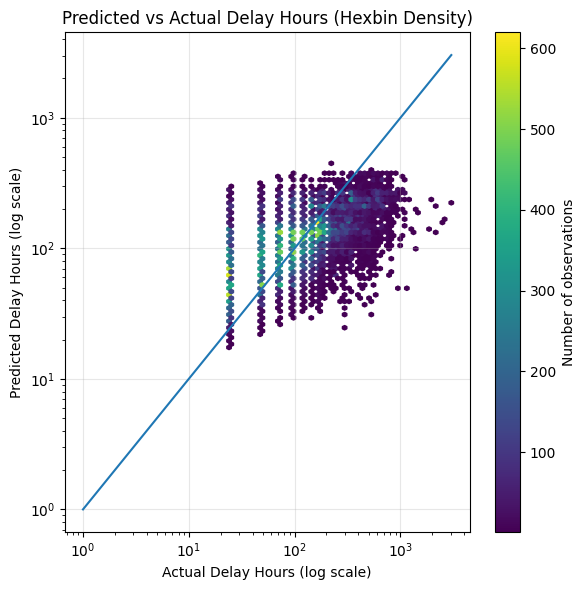

In [29]:
plt.figure(figsize=(6, 6))

hb = plt.hexbin(
    y_true_hours,
    y_pred_hours,
    gridsize=50,
    xscale="log",
    yscale="log",
    mincnt=1
)

max_val = max(y_true_hours.max(), y_pred_hours.max())
plt.plot([1, max_val], [1, max_val])

plt.xlabel("Actual Delay Hours (log scale)")
plt.ylabel("Predicted Delay Hours (log scale)")
plt.title("Predicted vs Actual Delay Hours (Hexbin Density)")

cb = plt.colorbar(hb)
cb.set_label("Number of observations")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


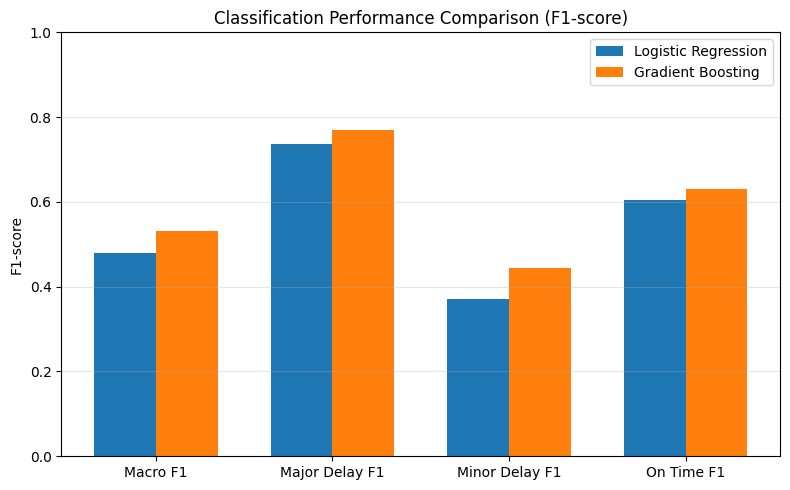

In [30]:


# Logistic Regression metrics
lr_report = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

# Gradient Boosting metrics
gb_report = classification_report(
    y_test,
    y_pred_gb,
    output_dict=True
)

metrics = pd.DataFrame({
    "Metric": ["Macro F1", "Major Delay F1", "Minor Delay F1", "On Time F1"],
    "Logistic Regression": [
        lr_report["macro avg"]["f1-score"],
        lr_report["Major Delay"]["f1-score"],
        lr_report["Minor Delay"]["f1-score"],
        lr_report["On Time"]["f1-score"],
    ],
    "Gradient Boosting": [
        gb_report["macro avg"]["f1-score"],
        gb_report["Major Delay"]["f1-score"],
        gb_report["Minor Delay"]["f1-score"],
        gb_report["On Time"]["f1-score"],
    ]
})

# ---- Plot (old style) ----
x = np.arange(len(metrics["Metric"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    metrics["Logistic Regression"],
    width,
    label="Logistic Regression"
)

ax.bar(
    x + width / 2,
    metrics["Gradient Boosting"],
    width,
    label="Gradient Boosting"
)

ax.set_ylabel("F1-score")
ax.set_title("Classification Performance Comparison (F1-score)")
ax.set_xticks(x)
ax.set_xticklabels(metrics["Metric"])
ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


MAE check: 82.92630533788
p50 / p75 / p90 / p95: [ 47.84357153  98.53445166 194.72086115 308.94592574]


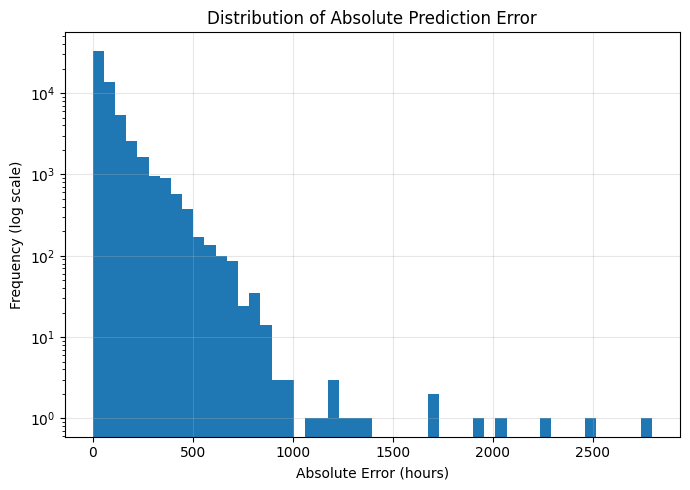

In [32]:
abs_error = np.abs(y_true_hours - y_pred_hours)

print("MAE check:", abs_error.mean())
print(
    "p50 / p75 / p90 / p95:",
    np.percentile(abs_error, [50, 75, 90, 95])
)

plt.figure(figsize=(7, 5))

plt.hist(
    abs_error,
    bins=50,
    log=True
)

plt.xlabel("Absolute Error (hours)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Absolute Prediction Error")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
